# Influence of Load Level

In [1]:
# Import settings and constants
import os   # module for interfacing with the underlying operating system
import sys  # module for interacting with the Python interpreter

# Add parent directory to path and import settings
parent_directory = os.path.join(os.path.dirname(os.getcwd()))
sys.path.append(parent_directory)
from settings import *

# Add main directory of repository to path
main_directory = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(main_directory)

# Define name of directory where to save analyses and figures
FIGURES_DIRECTORY_PATH = os.getcwd()
DATA_DIRECTORY_PATH = r"C:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\analyses\23_Optimization_of_the_CRM-like_Box_Beam_under_Combined_Bending_and_Torsional_Load"

# Allow for interactive plots
%matplotlib widget

Define constants of the model.

In [2]:
import numpy as np  # module for numerical operations

L = 29.38e3  # [mm] wingbox length
W = 3.41e3  # [mm] wingbox width
H = 0.77e3  # [mm] wingbox height
H_A = H / 15  # [mm] skin arc height
H_S = H / 10  # [mm] stiffener height
no_stiffeners = 2  # number of stiffeners
stiffeners_x_locations = np.linspace(0, W, no_stiffeners + 2)[
    1:-1
]  # [mm] stiffeners x-coordinates
stiffeners_spacing = W / (no_stiffeners + 1)  # [mm] stiffeners spacing
ribs_spacing = stiffeners_spacing * 1.4  # [mm] ribs spacing
no_ribs = round(L / ribs_spacing) + 1  # number of ribs
ribs_y_locations = np.linspace(0, L, no_ribs)  # [mm] ribs y-coordinates

## Initial structure

Plot critical buckling mode of initial structure.

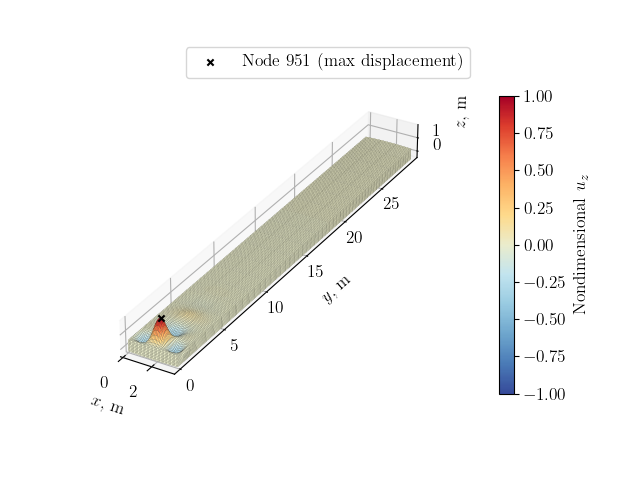

In [3]:
from pyNastran.op2.op2 import read_op2
from resources import plot_utils


# Define function to adjust axes ticks and labels' position
def adjust_3d_plot(axes, colorbar=None):
    axes.locator_params(axis="x", nbins=3)  # set number of ticks of x-axis
    axes.locator_params(axis="z", nbins=2)  # set number of ticks of z-axis
    axes.tick_params(
        axis="y", which="major", pad=25
    )  # adjust position of ticks' label of y-axis
    axes.tick_params(
        axis="z", which="major", pad=6
    )  # adjust position of ticks' label of z-axis
    axes.yaxis.labelpad = 90  # adjust position of y-axis's label
    axes.zaxis.labelpad = 10  # adjust position of z-axis's label
    if colorbar is not None:
        colorbar.ax.set_position(
            colorbar.ax.get_position().shrunk(1.0, 0.62)
        )  # decrease colorbar size
        colorbar.ax.set_position(
            colorbar.ax.get_position().translated(-0.07, 0.18)
        )  # move colorbar upwards


# Plot buckling mode
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})
input_name = f"sol_105_t15p4"
op2_filepath = os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2")
sol_105_op2_initial = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)
amplification_factor = 1.5  # amplification factor for displacements
clim = [-1, 1]  # colorbar limits
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_initial,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    length_unit="m",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=1e-3,
    clim=clim,
)

# Plot node where maximum displacement occurs
root_node_id = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_initial,
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=1e-3,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
BBOX_COLORBAR = fig.bbox_inches.from_bounds(
    0.8, 0.5, 5.2, 3.9
)  # create bounding box for figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"IncreasedLoadInitialCriticalBucklingMode.png"
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot nonlinear response of initial structure.

C:\Users\qa21944\AppData\Local\Temp\ipykernel_19668\2509735384.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


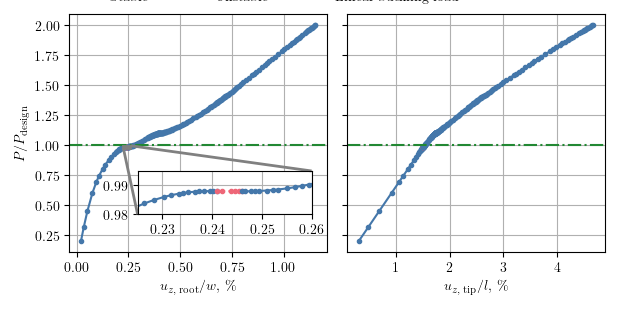

In [4]:
from resources import pynastran_utils
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# Find ids of tip nodes and add to dictionary of plot nodes
tip_node_xyz = np.array([W / 2, L, 0])  # tip node is taken at the center of the tip rib
tip_node_id = (
    np.argmin(
        np.linalg.norm(
            np.array([sol_105_op2_initial.nodes[i].xyz for i in sol_105_op2_initial.nodes])
            - tip_node_xyz,
            axis=1,
        )
    )
    + 1  # argmin finds index of the node, add 1 to get id
)

# Define list with ids of nodes to plot
plot_nodes_ids = [root_node_id, tip_node_id]


# Define function to plot load-displacement diagram
def plot_load_displacement_diagram(
    input_name, plot_nodes_ids, reference_lengths, load_factor_multiplier=1
):
    # Create one figure with two subplots side by side
    fig, axes = plt.subplots(
        1,
        len(plot_nodes_ids),
        sharey=True,
        figsize=(TEXTWIDTH_INCHES, TEXTWIDTH_INCHES * 0.5),
    )

    # Read eigenvalues
    f06_path = os.path.join(
        DATA_DIRECTORY_PATH, input_name + ".f06"
    )  # path to .f06 file
    eigenvalues = pynastran_utils.read_kllrh_lowest_eigenvalues_from_f06(f06_path)

    # Read load and displacement histories
    sol_106_op2 = read_op2(
        os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2"),
        load_geometry=True,
        debug=None,
    )
    load_factors, _, displacements = (
        pynastran_utils.read_load_displacement_history_from_op2(
            op2=sol_106_op2, node_ids=plot_nodes_ids
        )
    )
    nondimensional_loads = load_factors[FIRST_SUBCASE_ID] * load_factor_multiplier

    # Iterate over nodes to plot and plot load-displacement diagram
    for i, node_id in enumerate(plot_nodes_ids):
        plot_utils.plot_2d_load_displacements_stability(
            axes[i],
            displacements[node_id][FIRST_SUBCASE_ID][:, Z_INDEX]
            / reference_lengths[i]
            * 100,
            nondimensional_loads,
            eigenvalues,
            MARKERS[0],
            COLORS[0],
        )

    # Return
    return (
        fig,
        axes,
        sol_106_op2,
        displacements,
        nondimensional_loads,
        eigenvalues,
    )


# Plot load-displacement diagrams
input_name = "sol_106_t15p4"
reference_lengths = [
    W,
    L,
]  # reference lengths for nondimensionalization of displacements
(
    fig,
    axes,
    sol_106_op2,
    displacements,
    nondimensional_loads,
    eigenvalues,
) = plot_load_displacement_diagram(
    input_name, plot_nodes_ids, reference_lengths, load_factor_multiplier=2
)

# Plot linear buckling load lines
for ax in axes:
    ax.axhline(y=1.0, color=GLASS_CEILING_COLOR, linestyle="-.")

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[1].grid(visible=True)

# Create zoomed inset in root displacement plot
x1, x2 = 0.225, 0.26  # x-interval of interest for the first zoomed inset
y1, y2 = 0.98, 0.995  # y-interval of interest for the first zoomed inset
axins = zoomed_inset_axes(
    axes[0], zoom=24.0, bbox_to_anchor=(-0.11, 0.37), bbox_transform=ax.transAxes
)
plot_utils.plot_2d_load_displacements_stability(
    axins,
    displacements[root_node_id][FIRST_SUBCASE_ID][:, Z_INDEX] / W * 100,
    nondimensional_loads,
    eigenvalues,
    MARKERS[0],
    COLORS[0],
)
axins.set_xlim(x1, x2)  # Adjust the limits as needed
axins.set_ylim(y1, y2)  # Adjust the limits as needed
# axins.tick_params(labelleft=False, labelbottom=False)
axins.grid(True)
mark_inset(
    axes[0], axins, loc1=3, loc2=1, fc="none", ec="0.5", linewidth=2, zorder=2
)  # Connect to the region of interest

# Ensures proper spacing between subplots
plt.tight_layout()

# Create proxy artists for legend
stable_line = Line2D([0], [0], linestyle="-", color=COLORS[0], label="Stable")
unstable_line = Line2D([0], [0], linestyle="--", color=UNSTABLE_COLOR, label="Unstable")
glass_ceiling_line = Line2D(
    [0], [0], linestyle="-.", color=GLASS_CEILING_COLOR, label="Linear buckling load"
)
axes[0].legend(
    handles=[stable_line, unstable_line, glass_ceiling_line],
    loc="upper left",
    ncols=3,
    bbox_to_anchor=(-0.04, 1.15),
    frameon=False,
)  # add legend after tight_layout

# Show plot and save figure
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadInitialLoadDisplacement.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Print nondimensional limit point load.

In [5]:
first_negative_eigenvalue_index = np.where(eigenvalues[0] < 0)[0][
    0
]  # find index of first negative eigenvalue
limit_point_load = np.mean(
    nondimensional_loads[
        first_negative_eigenvalue_index - 1 : first_negative_eigenvalue_index + 1
    ]
)

Compare deformation before and after snap-through.

Deformation before snap:


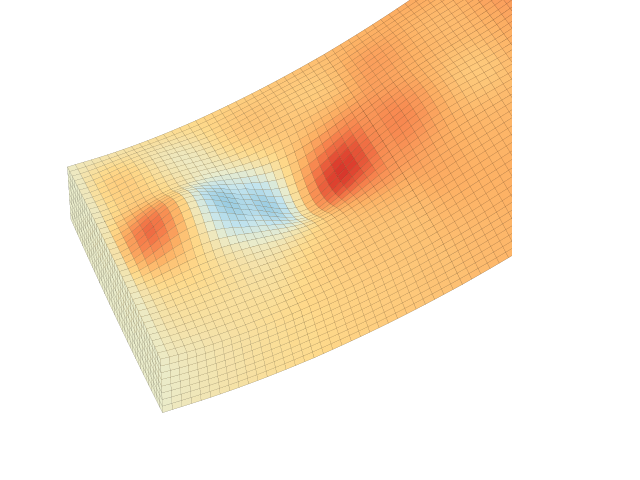

Deformation after snap


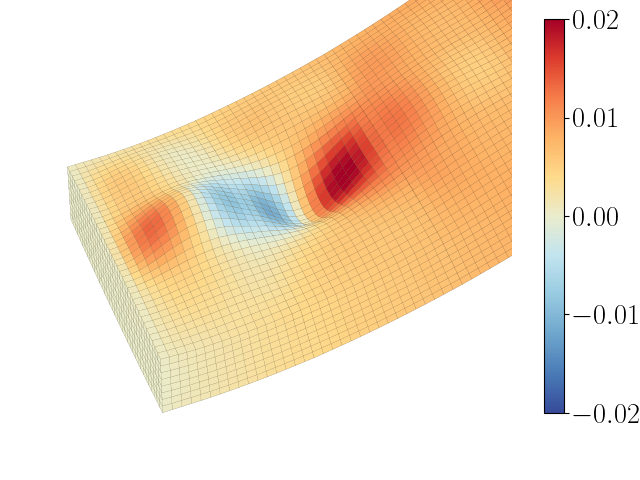

In [6]:
# Increase font size because figures are rendered side by side in the paper
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.49)})


# Define function to zoom deformation plot to root
def zoom_to_root(axes):
    axes.set_xlim(0, W * 1e-3)
    axes.set_ylim(0, 5 * H * 1e-3)
    axes.set_zlim(-H / 2 * 1e-3, H * 1e-3)
    axes.set_box_aspect(
        [ub - lb for lb, ub in (getattr(axes, f"get_{a}lim")() for a in "xyz")]
    )
    plt.axis("off")
    axes.view_init(40, -20)


# Plot deformation just before limit point
key = "curved skin"
print("Deformation before snap:")
amplification_factor = 60  # amplification factor for displacements
clim = [-0.02, 0.02]  # color limits for deformation plot
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2,
    subcase_id=FIRST_SUBCASE_ID,
    load_step=first_negative_eigenvalue_index,
    displacement_component="rx",
    colormap="sunset",
    length_unit="m",
    unit_scale_factor=1e-3,
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.remove()
zoom_to_root(ax)
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadBeforeSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Plot deformation just after snap
skip = 10  # number of increments to skip for selection of applied load after snap
subsequent_values = nondimensional_loads[
    first_negative_eigenvalue_index + skip :
]  # consider only applied loads after snap
closest_index_in_subsequent = np.argmin(
    np.abs(limit_point_load - subsequent_values)
)  # find index of closest value to applied load at first limit point
closest_index = (
    first_negative_eigenvalue_index + skip + closest_index_in_subsequent
)  # sum found index to index of first negative eigenvalue
print("Deformation after snap")
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2,
    subcase_id=FIRST_SUBCASE_ID,
    load_step=closest_index + 1,
    displacement_component="rx",
    colormap="sunset",
    length_unit="m",
    unit_scale_factor=1e-3,
    displacement_amplification_factor=amplification_factor,
    clim=clim,
)  # plot buckling mode converting from mm to m
adjust_3d_plot(ax)
cbar.ax.set_position(cbar.ax.get_position().shrunk(1.0, 0.82))  # decrease colorbar size
cbar.ax.set_position(
    cbar.ax.get_position().translated(0, 0.14)
)  # move colorbar upwards
zoom_to_root(ax)
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadAfterSnap.png"),
    bbox_inches="tight",
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

## Linear Buckling Optimization

Plot linear buckling optimization history.

Requested variables at last iteration:
- interp.t_cp: [16.07100661  2.71595013]
- nastran_solver.ks_buckling: [0.00074702]
- nastran_solver.ks_stress: [-324.20196533]
- nastran_solver.mass: [8.07198012]


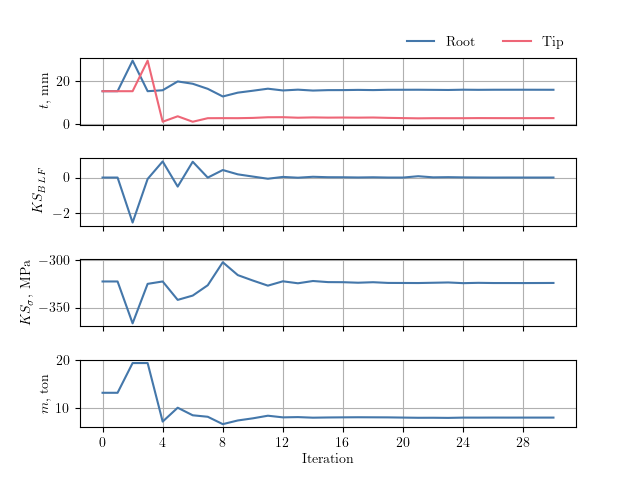

In [7]:
from resources import optimization_utils


# Read linear buckling optimization history
recorder_filename = "sol_105_increased_load_linear_opt.sql"
y_labels = ["$t$, mm", "$KS_{BLF}$", "$KS_\sigma$, MPa", "$m$, ton"]
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, linear_opt_histories = (
    optimization_utils.plot_optimization_history(recorder_filepath, y_labels=y_labels)
)  # plot optimization history

# Add legend to thickness plot
axes[0].legend(
    ["Root", "Tip"],
    loc="upper right",
    bbox_to_anchor=(1.0, 1.5),
    ncol=2,
    frameon=False,
)

# Save figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadLinearOptHistories.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)


Plot critical buckling mode of linearly optimized structure.

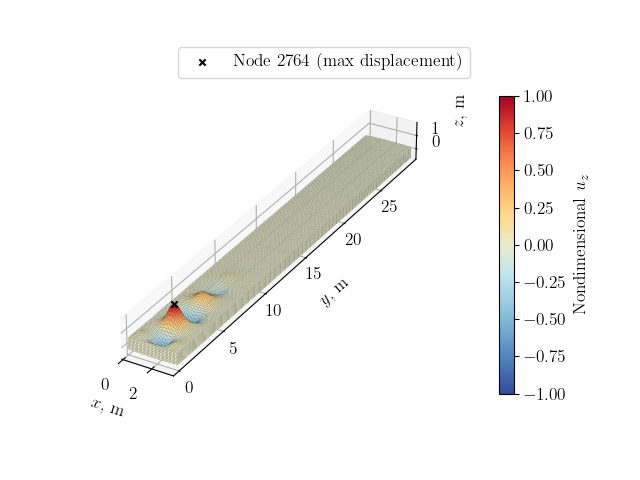

In [8]:
# Plot buckling mode
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})
input_name = f"sol_105_increased_load_linear_opt"
op2_filepath = os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2")
sol_105_op2_linear_opt = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)
amplification_factor = 1.5  # amplification factor for displacements
clim = [-1, 1]  # colorbar limits
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_linear_opt,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    length_unit="m",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=1e-3,
    clim=clim,
)

# Plot node where maximum displacement occurs
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_linear_opt,
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=1e-3,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"IncreasedLoadLinearOptCriticalBucklingMode.png"
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot nonlinear response of linearly optimized structure.

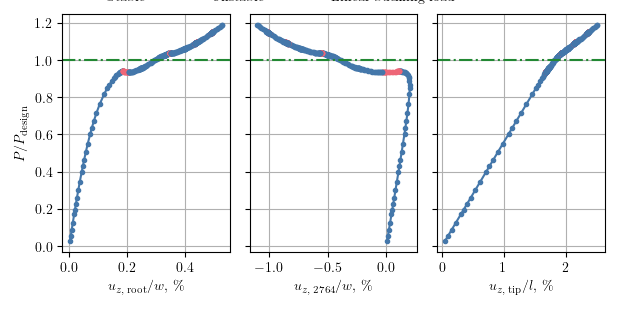

In [9]:
# Plot load-displacement diagrams
input_name = "sol_106_increased_load_linear_opt"
plot_nodes_ids.insert(1, max_disp_node_id)
reference_lengths = [
    W,
    W,
    L,
]  # reference lengths for nondimensionalization of displacements
(
    fig,
    axes,
    sol_106_op2,
    displacements,
    nondimensional_loads,
    eigenvalues,
) = plot_load_displacement_diagram(
    input_name, plot_nodes_ids, reference_lengths, load_factor_multiplier=2
)

# Plot linear buckling load lines
for ax in axes:
    ax.axhline(y=1.0, color=GLASS_CEILING_COLOR, linestyle="-.")

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel(f"$u_{{z,\,{max_disp_node_id:d}}}/w$, \%")
axes[1].grid(visible=True)

# Set plot appearance for the second subplot
axes[2].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[2].grid(visible=True)

# Ensures proper spacing between subplots
plt.tight_layout()

# Create legend after tight_layout
axes[0].legend(
    handles=[stable_line, unstable_line, glass_ceiling_line],
    loc="upper left",
    ncols=3,
    bbox_to_anchor=(-0.04, 1.15),
    frameon=False,
)

# Show plot and save figure
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadLinearOptLoadDisplacement.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

## Nonlinear Structural Stability Optimization

Plot nonlinear structural stability optimization history.

Requested variables at last iteration:
- interp.t_cp: [16.61230705  1.45563342]
- nastran_solver.ks_stability: [5.041061]
- nastran_solver.ks_stress: [-327.80303955]
- nastran_solver.load_factor: [0.98999763]
- nastran_solver.mass: [7.7630485]


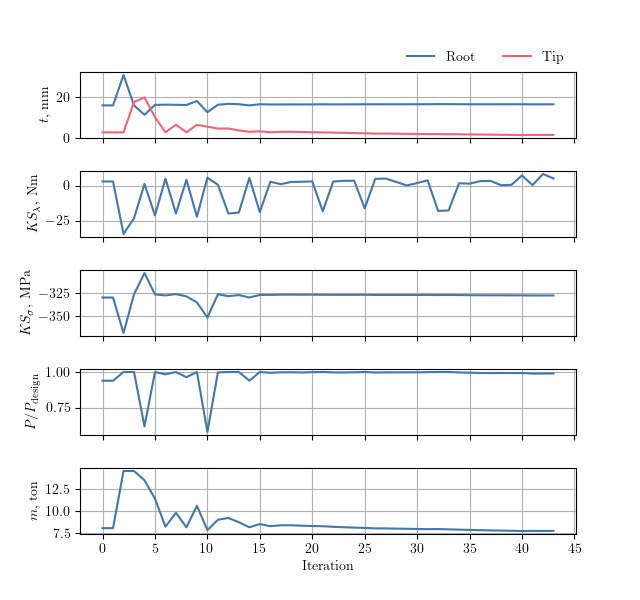

In [10]:
# Read linear buckling optimization history
recorder_filename = "sol_106_increased_load_nonlinear_opt.sql"
y_labels = [
    "$t$, mm",
    "$KS_\lambda$, Nm",
    "$KS_\sigma$, MPa",
    "$P/P_\mathrm{design}$",
    "$m$, ton",
]
recorder_filepath = os.path.join(DATA_DIRECTORY_PATH, recorder_filename)
fig, axes, nonlinear_opt_histories = (
    optimization_utils.plot_optimization_history(recorder_filepath, y_labels=y_labels)
)  # plot optimization history

# Add legend to thickness plot
axes[0].legend(
    ["Root", "Tip"],
    loc="upper right",
    bbox_to_anchor=(1.0, 1.5),
    ncol=2,
    frameon=False,
)

# Save figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadNonlinearOptHistories.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Compare linearly optimized thickness distribution with nonlinearly optimized thickness distribution.

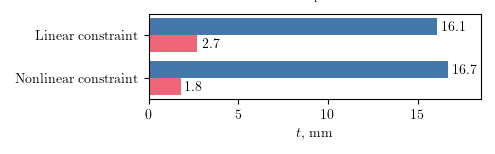

In [11]:
# Find feasible design index of nonlinear structural stability optimization
feasible_design_index = np.where(nonlinear_opt_histories['nastran_solver.ks_stability'][:, 0] < 1e-3)[0][-1]


# Define function to plot bar chart of final thicknesses
def plot_thickness_bar_chart(
    linear_opt_histories,
    nonlinear_opt_histories,
    figure_filename,
    iter_indices=[-1, -1],
):
    # Set up data for the bar chart
    constraints = ["Linear constraint", "Nonlinear constraint"]
    final_thicknesses = {
        "$t_\mathrm{root}$": (
            linear_opt_histories["interp.t_cp"][iter_indices[0], 0],
            nonlinear_opt_histories["interp.t_cp"][iter_indices[1], 0],
        ),
        "$t_\mathrm{tip}$": (
            linear_opt_histories["interp.t_cp"][iter_indices[0], 1],
            nonlinear_opt_histories["interp.t_cp"][iter_indices[1], 1],
        ),
    }

    # Plot bar chart with final thicknesses
    y_pos = np.arange(len(constraints))  # the label locations
    height = 0.4  # the height of the bars
    multiplier = 0.5  # multiplier to separate bars
    fig, ax = plt.subplots(
        figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.25)
    )  # create figure and axis
    for (
        attribute,
        values,
    ) in final_thicknesses.items():  # iterate over attributes and values
        offset = height * multiplier  # offset to separate bars
        rects = ax.barh(y_pos + offset, values, height, label=attribute)  # plot bars
        ax.bar_label(rects, padding=3, fmt="{:,.1f}")  # add labels to bars
        multiplier += 1.0  # increase multiplier to separate bars

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_xlabel("$t$, mm")
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_yticks(y_pos + height, constraints)
    ax.set_xlim(
        right=max(max(v) for v in final_thicknesses.values()) + 1.8
    )  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    ax.legend(
        bbox_to_anchor=(0.03, 1.01), ncols=2, frameon=False
    )  # add legend after tight layout
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )

# Plot bar chart with final thicknesses
figure_name = "IncreasedLoadThicknesses"
plot_thickness_bar_chart(
    linear_opt_histories, nonlinear_opt_histories, figure_name, [-1, feasible_design_index]
)

Compare linearly optimized mass with nonlinearly optimized mass.

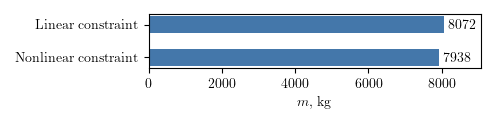

Percentage difference: -1.66 %


In [12]:
# Define function to plot bar chart of final thicknesses
def plot_final_mass_bar_chart(
    linear_opt_histories,
    nonlinear_opt_histories,
    figure_filename,
    iter_indices=[-1, -1],
):

    # Find final masses of curved and flat skin model
    constraints = ["Linear constraint", "Nonlinear constraint"]
    final_masses = np.array(
        [
            linear_opt_histories["nastran_solver.mass"][iter_indices[0], 0],
            nonlinear_opt_histories["nastran_solver.mass"][iter_indices[1], 0],
        ]
    )

    # Make bar chart
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.2))
    y_pos = np.arange(len(constraints))  # position of bars
    p = ax.barh(y_pos, final_masses * 1e3, height=0.5)  # plot bars
    ax.bar_label(p, padding=3, fmt="{:.0f}")  # add labels to bars
    ax.set_yticks(y_pos, labels=constraints)  # set labels of y-axis
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel("$m$, kg")  # set label of x-axis
    ax.set_xlim(right=np.max(final_masses) * 1e3 + 1e3)  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )

    # Print percentage difference
    print(f"Percentage difference: {(final_masses[1]/final_masses[0] - 1)*100:.2f} %")


# Plot bar chart with final thicknesses
figure_name = "IncreasedLoadMasses"
plot_final_mass_bar_chart(
    linear_opt_histories, nonlinear_opt_histories, figure_name, [-1, feasible_design_index]
)

Compare twist along the length of the structure.

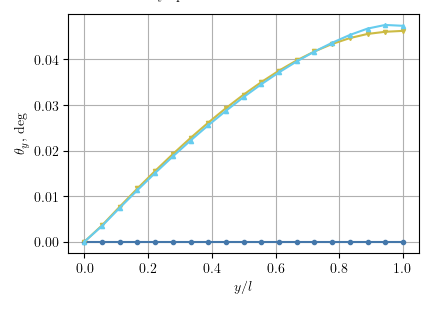

In [13]:
from resources import pynastran_utils


# Define function to calculate twist based on the vertical displacement of front and rear node of each rib
def calculate_twist(front_node_coord, front_node_disp, rear_node_coord, rear_node_disp):
    delta_theta = np.arctan(
        (
            (front_node_coord[Z_INDEX] + front_node_disp[Z_INDEX])
            - (rear_node_coord[Z_INDEX] + rear_node_disp[Z_INDEX])
        )
        / (
            (rear_node_coord[X_INDEX] + rear_node_disp[X_INDEX])
            - (front_node_coord[X_INDEX] + front_node_disp[X_INDEX])
        )
    ) - np.arctan(
        (front_node_coord[Z_INDEX] - rear_node_coord[Z_INDEX])
        / (rear_node_coord[X_INDEX] - front_node_coord[X_INDEX])
    )
    return delta_theta


# Read SOL 106 op2 file of nonlinearly optimized structure under bending and torsion loading
op2_filepath = os.path.join(
    DATA_DIRECTORY_PATH, "sol_106_increased_load_nonlinear_opt_feasible.op2"
)
sol_106_op2_nonlinear_opt = read_op2(
    op2_filename=op2_filepath, load_geometry=True, debug=None
)

# Create dictionary with op2 objects of model under bending and torsion loading
twist_op2_dict = {
    "Initial - SOL 105": sol_105_op2_initial,
    "Linearly optimized - SOL 105": sol_105_op2_linear_opt,
    "Nonlinearly optimized - SOL 106": sol_106_op2_nonlinear_opt,
}

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))

# Iterate over the op2 objects in the dictionary
for i, key in enumerate(twist_op2_dict):

    # Find coordinates of all nodes
    nodes_xyz = np.vstack([grid.xyz for grid in twist_op2_dict[key].nodes.values()])

    # Initialize arrays to store node coordinates and ids
    front_nodes_xyz = np.zeros((len(ribs_y_locations), 3))
    front_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    central_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    rear_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    rear_nodes_xyz = np.zeros((len(ribs_y_locations), 3))

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):

        # Find front node id
        front_nodes_xyz[j] = np.array([0, rib_y, H/2])
        front_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - front_nodes_xyz[j], axis=1)) + 1
        )

        # Find central node id
        central_node_xyz = np.array([W / 2, rib_y, H/2])
        central_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - central_node_xyz, axis=1)) + 1
        )

        # Find rear node id
        rear_nodes_xyz[j] = np.array([W, rib_y, H/2])
        rear_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - rear_nodes_xyz[j], axis=1)) + 1
        )

    # Read displacement data from OP2 object
    displacements = pynastran_utils.read_displacement_from_op2(
        op2=twist_op2_dict[key],
        node_ids=np.hstack([front_nodes_ids, central_nodes_ids, rear_nodes_ids]),
    )

    # Initialize array to store twist angles
    twist_angles = np.zeros_like(ribs_y_locations)

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):
        # Calculate twist angle from displacements of front and rear nodes
        twist_angles[j] = calculate_twist(
            front_nodes_xyz[j],
            displacements[front_nodes_ids[j]][FIRST_SUBCASE_ID],
            rear_nodes_xyz[j],
            displacements[rear_nodes_ids[j]][FIRST_SUBCASE_ID],
        )

    # Plot twist angles
    ax.plot(
        ribs_y_locations / L,
        np.degrees(twist_angles),
        label=key,
        color=COLORS[i],
        marker=MARKERS[i],
    )

# Set labels and grid
ax.set_ylabel(r"$\theta_y$, deg")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.71, 1.2), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "IncreasedLoadTwistComparison.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot critical buckling mode of nonlinearly optimized structure.

P/P_SOL105 = 0.35


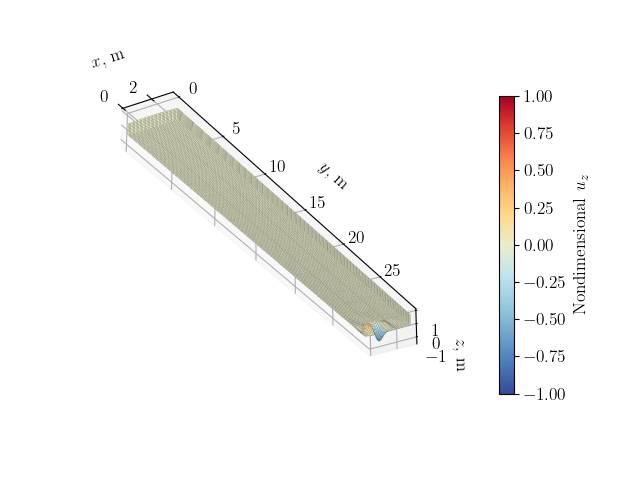

In [14]:
# Increase font and marker size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})

# Read op2 file
input_name = f"sol_105_increased_load_nonlinear_opt"
op2_filepath = os.path.join(DATA_DIRECTORY_PATH, input_name + ".op2")
sol_105_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)

# Print linear buckling load
buckling_load_factor = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigrs[0]
print(f"P/P_SOL105 = {buckling_load_factor:.2f}")

# Plot buckling mode
amplification_factor = 1.5  # amplification factor for displacements
clim = [-1, 1]  # colorbar limits
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    length_unit="m",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=1e-3,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
ax.view_init(-30, -60)
ax.tick_params(axis="y", which="major", pad=40)  # adjust position of ticks' label of y-axis
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"IncreasedLoadNonlinearOptCriticalBucklingMode.png"
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot nonlinear response of nonlinearly optimized structure.

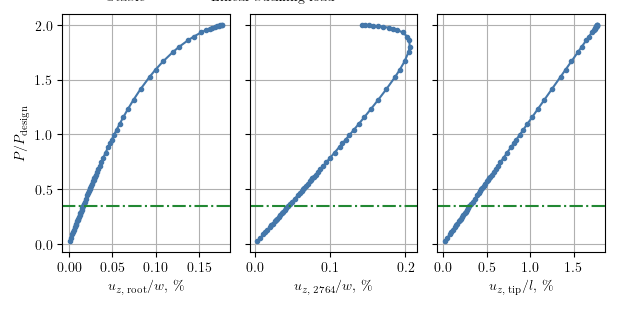

In [15]:
# Plot load-displacement diagrams
input_name = "sol_106_increased_load_nonlinear_opt_feasible"
(
    fig,
    axes,
    sol_106_op2,
    displacements,
    nondimensional_loads,
    eigenvalues,
) = plot_load_displacement_diagram(
    input_name, plot_nodes_ids, reference_lengths, load_factor_multiplier=2
)

# Plot linear buckling load lines
for ax in axes:
    ax.axhline(y=buckling_load_factor, color=GLASS_CEILING_COLOR, linestyle="-.")

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel(f"$u_{{z,\,{max_disp_node_id:d}}}/w$, \%")
axes[1].grid(visible=True)

# Set plot appearance for the second subplot
axes[2].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[2].grid(visible=True)

# Ensures proper spacing between subplots
plt.tight_layout()

# Create legend after tight_layout
axes[0].legend(
    handles=[stable_line, glass_ceiling_line],
    loc="upper left",
    ncols=3,
    bbox_to_anchor=(-0.04, 1.15),
    frameon=False,
)

# Show plot and save figure
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, "IncreasedLoadNonlinearOptLoadDisplacement.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0,
)

Plot deformation at design load.

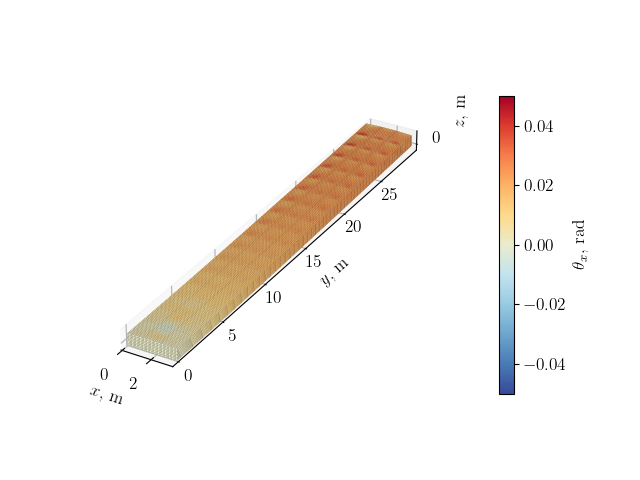

In [16]:
# Plot deformation
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})
clim = [-0.05, 0.05]
fig, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2,
    subcase_id=FIRST_SUBCASE_ID,
    displacement_component="rx",
    colormap="sunset",
    length_unit="m",
    unit_scale_factor=1e-3,
    clim=clim,
)
adjust_3d_plot(ax, cbar)
ax.set_zticks([0])
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"IncreasedLoadNonlinearOptDeformation.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default font size
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})